In [6]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\rk307
['-1.14-windows.xml', '.anaconda', '.android', '.bubblewrap', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.emulator_console_auth_token', '.gitconfig', '.gradle', '.ipynb_checkpoints', '.ipython', '.jupyter', '.mamba', '.matplotlib', '.VirtualBox', '.vscode', '.vscode-shared', 'AndroidStudioProjects', 'AppData', 'Application Data', 'candid', 'candid.zip', 'Cookies', 'Documents', 'Downloads', 'Dropbox', 'Favorites', 'Local Settings', 'module 1', 'module SO7', 'monster-hunter-online', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'perovskites_data.csv', 'perovskites_report.html', 'Pictures', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'Sen

In [7]:
import pandas as pd
import seaborn as sns

df = pd.read_csv("perovskites_data.csv")

duplicates = df.duplicated(subset=["Formula"], keep=False)

print(f"Duplicate entries found: {duplicates.sum()}")

df[duplicates]

Duplicate entries found: 2716


,Material_ID,Formula,Bandgap,Formation_Energy,Volume
14,mp-36600,Ag3SBr,0.3977,-0.335732,233.827014
15,mp-1105645,Ag3SBr,0.2964,-0.305716,484.805518
16,mp-1229116,Ag3SBr,0.3987,-0.340330,118.090939
17,mp-22995,Ag3SI,0.5390,-0.260466,121.855550
18,mp-558189,Ag3SI,0.6243,-0.210889,125.720329
...,...,...,...,...,...
4707,mp-1068577,ZrPbO3,2.2842,-2.793935,74.561741
4708,mp-1100803,ZrPbO3,2.6291,-2.839739,305.718552
4709,mp-aaaieixs,ZrPbO3,3.3665,-2.694134,163.339256
4717,mp-1016883,ZrZnO3,0.0000,-2.246558,71.115505


In [8]:
# Assume 'df' is the cleaned dataset from Session S10
# 1. Detect Duplicates by Formula
duplicates = df.duplicated(subset=['Formula'], keep=False)
print(f"Duplicate entries found: {duplicates.sum()}")

Duplicate entries found: 2716


<Axes: xlabel='Bandgap'>

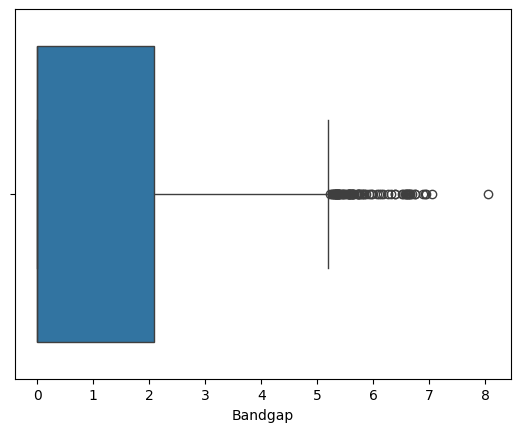

In [9]:
# 2. Visual Outlier Detection (Boxplot)
sns.boxplot(x=df['Bandgap'])

In [10]:
# 3. Mathematical Outlier Detection (IQR Method)
Q1 = df['Bandgap'].quantile(0.25)
Q3 = df['Bandgap'].quantile(0.75)
IQR = Q3 - Q1

In [11]:
# Filter out the anomalies
outliers = df[(df['Bandgap'] < (Q1 - 1.5 * IQR)) | (df['Bandgap'] > (Q3 + 1.5 * IQR))]
print(f"Mathematical outliers detected: {len(outliers)}")

Mathematical outliers detected: 83
